# 🧬 Embryo Development Stage Classification
### Multi-class classification across 15 embryo development phases
**Models:** MobileNetV2 | InceptionV3 | VGG16 | VGG19  
**Dataset:** [abhishekbuddiga06/embryo-dataset](https://www.kaggle.com/datasets/abhishekbuddiga06/embryo-dataset)  
**Pipeline:** Stage 1 (CrossEntropy, frozen) → Stage 2 (HybridLoss, unfrozen)

##  Cell 1 — Install Dependencies

In [1]:

!pip install kagglehub -q
!pip install torchvision scikit-learn tqdm matplotlib seaborn -q
print(' All packages ready')

 All packages ready


##  Cell 2 — Kaggle Authentication & Dataset Download

In [2]:
import kagglehub
import os
path = kagglehub.dataset_download('abhishekbuddiga06/embryo-dataset')
print('✅ Dataset path:', path)
print('Contents:', os.listdir(path))

Using Colab cache for faster access to the 'embryo-dataset' dataset.
✅ Dataset path: /kaggle/input/embryo-dataset
Contents: ['embryo_dataset', 'embryo_dataset_annotations']


##  Cell 3 — Locate Dataset Folders

In [3]:
import os

def find_dir(root, keyword):
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if keyword.lower() in d.lower():
                return os.path.join(dirpath, d)
    return None

DATA_DIR = find_dir(path, 'embryo_dataset')
ANN_DIR  = find_dir(path, 'annotations')

if DATA_DIR and os.path.basename(DATA_DIR).lower() in [d.lower() for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]:
    DATA_DIR = os.path.join(DATA_DIR, os.path.basename(DATA_DIR))

if ANN_DIR and os.path.basename(ANN_DIR).lower() in [d.lower() for d in os.listdir(ANN_DIR) if os.path.isdir(os.path.join(ANN_DIR, d))]:
    ANN_DIR = os.path.join(ANN_DIR, os.path.basename(ANN_DIR))


if ANN_DIR is None or not (os.path.isdir(ANN_DIR) and any(f.endswith('.csv') for f in os.listdir(ANN_DIR))):
    for dirpath, _, files in os.walk(path):
        if any(f.endswith('.csv') for f in files):
            ANN_DIR = dirpath
            break

if DATA_DIR is None:
    for dirpath, dirnames, _ in os.walk(root):
        if len(dirnames) > 10:
            DATA_DIR = dirpath
            break

print(' Images dir  :', DATA_DIR)
print(' Annot. dir  :', ANN_DIR)
print('   # embryos   :', len(os.listdir(DATA_DIR)) if DATA_DIR else 'NOT FOUND')
print('   # ann files :', len(os.listdir(ANN_DIR))  if ANN_DIR  else 'NOT FOUND')

 Images dir  : /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset
 Annot. dir  : /kaggle/input/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations
   # embryos   : 704
   # ann files : 704


## 🔧 Cell 4 — Imports & Global Config

In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image, ImageFile

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('  Device :', DEVICE)
if torch.cuda.is_available():
    print('   GPU    :', torch.cuda.get_device_name(0))

# ── Hyper-params ─────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 8
STAGE1_LR   = 1e-3   # frozen backbone
STAGE2_LR   = 1e-4   # fine-tuning
STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 5
SAMPLE_RATE   = 10

PHASES = ['tPB2','tPNa','tPNf','t2','t3','t4','t5',
          't6','t7','t8','t9+','tM','tSB','tB','tEB']
NUM_CLASSES = len(PHASES)   # 15
LABEL_MAP   = {p: i for i, p in enumerate(PHASES)}

print(f'\n Classes ({NUM_CLASSES}):', PHASES)

  Device : cuda
   GPU    : Tesla T4

 Classes (15): ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tM', 'tSB', 'tB', 'tEB']


##  Cell 5 — Build DataFrame from Annotations

In [5]:
def build_dataframe(data_dir, ann_dir, sample_rate=SAMPLE_RATE):
    """Parse annotation CSVs → DataFrame of (image_path, label, embryo_id)."""
    rows = []
    print(f"ANN_DIR: {ann_dir}")
    print(f"Content of ANN_DIR: {os.listdir(ann_dir)}")
    csv_files = [f for f in os.listdir(ann_dir) if f.endswith('.csv')]
    print(f"Filtered CSV files: {csv_files}")

    for fname in tqdm(csv_files, leave=False, desc='Building dataset'):
        embryo_id  = fname.replace('_phases.csv', '')
        ann_path   = os.path.join(ann_dir, fname)
        img_folder = os.path.join(data_dir, embryo_id)

        print(f"Checking img_folder: {img_folder}")

        if not os.path.isdir(img_folder):
            print(f"  Folder NOT found: {img_folder}")
            continue

        images = sorted(os.listdir(img_folder))
        if not images:
            continue

        try:
            ann = pd.read_csv(ann_path, header=None)
            ann.columns = ['phase', 'start', 'end']
        except Exception:
            continue

        for _, row in ann.iterrows():
            phase = row['phase']
            if phase not in LABEL_MAP:
                continue
            label = LABEL_MAP[phase]
            for frame in range(int(row['start']), int(row['end']), sample_rate):
                if frame < len(images):
                    img_path = os.path.join(img_folder, images[frame])
                    rows.append({'image': img_path, 'label': label, 'embryo': embryo_id})

    return pd.DataFrame(rows)


df = build_dataframe(DATA_DIR, ANN_DIR)

print(f'\n Total samples : {len(df):,}')
if not df.empty:
    print(f'   Unique embryos : {df.embryo.nunique()}')
    print('\nClass distribution:')
    counts = df['label'].value_counts().sort_index()
    for i, c in counts.items():
        print(f'  [{i:2d}] {PHASES[i]:<6s} → {c:5d} samples')
else:
    print('   No samples loaded. Please check DATA_DIR and ANN_DIR paths.')


ANN_DIR: /kaggle/input/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations
Content of ANN_DIR: ['BC750-7_phases.csv', 'SK308-7_phases.csv', 'QC697-4_phases.csv', 'DI358-3_phases.csv', 'DV210-4_phases.csv', 'LV723-1_phases.csv', 'DS666-9_phases.csv', 'GJ285-1_phases.csv', 'PH394-2_phases.csv', 'DC307-1_phases.csv', 'GSS052-6_phases.csv', 'GE218-3_phases.csv', 'TM312-6_phases.csv', 'DN376-8_phases.csv', 'BC518-6_phases.csv', 'BC396-2_phases.csv', 'RE828-1_phases.csv', 'ND1068-3_phases.csv', 'BS495-9_phases.csv', 'LC648-1_phases.csv', 'BA25-7_phases.csv', 'TA757-9_phases.csv', 'MN011-3_phases.csv', 'BL042-8_phases.csv', 'WS1048-4_phases.csv', 'PMDPI029-1-1_phases.csv', 'BH034-4_phases.csv', 'RC545-2-8_phases.csv', 'TA656-2_phases.csv', 'CZ594-1_phases.csv', 'BI224-2_phases.csv', 'RG434-_10_phases.csv', 'KF460-4_phases.csv', 'LGA881-2-5_phases.csv', 'CL783-2_phases.csv', 'RV454-6_phases.csv', 'GE1055-6_phases.csv', 'RL461-4_phases.csv', 'RM126-11_phases.csv', 'BA518-7_phas

Building dataset:   0%|          | 1/704 [00:00<01:19,  8.87it/s]

Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/BC750-7
Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/SK308-7


Building dataset:   0%|          | 3/704 [00:00<01:11,  9.83it/s]

Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/QC697-4
Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/DI358-3
Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/DV210-4


...

Building dataset:  99%|█████████▉| 699/704 [00:58<00:00, 13.15it/s]

Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/GA664-1
Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/MM1134-3
Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/MC933-2


Building dataset: 100%|█████████▉| 703/704 [00:59<00:00, 12.51it/s]

Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/PI1004-3
Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/GS349-4
Checking img_folder: /kaggle/input/embryo-dataset/embryo_dataset/embryo_dataset/BL526-5



 Total samples : 33,049
   Unique embryos : 704

Class distribution:
  [ 0] tPB2   →  1129 samples
  [ 1] tPNa   →  4560 samples
  [ 2] tPNf   →   851 samples
  [ 3] t2     →  3181 samples
  [ 4] t3     →   754 samples
  [ 5] t4     →  3160 samples
  [ 6] t5     →  1073 samples
  [ 7] t6     →  1098 samples
  [ 8] t7     →  1284 samples
  [ 9] t8     →  3475 samples
  [10] t9+    →  5330 samples
  [11] tM     →  1921 samples
  [12] tSB    →  1900 samples
  [13] tB     →  1256 samples
  [14] tEB    →  2077 samples


##  Cell 6 — Train / Val / Test Split (embryo-level)

In [6]:

embryos = df['embryo'].unique()
train_ids, temp_ids = train_test_split(embryos, test_size=0.30, random_state=SEED)
val_ids,   test_ids = train_test_split(temp_ids, test_size=0.50, random_state=SEED)

train_df = df[df.embryo.isin(train_ids)].reset_index(drop=True)
val_df   = df[df.embryo.isin(val_ids)  ].reset_index(drop=True)
test_df  = df[df.embryo.isin(test_ids) ].reset_index(drop=True)

print(' Split sizes')
print(f'   Train : {len(train_df):,}  ({train_df.embryo.nunique()} embryos)')
print(f'   Val   : {len(val_df):,}   ({val_df.embryo.nunique()} embryos)')
print(f'   Test  : {len(test_df):,}   ({test_df.embryo.nunique()} embryos)')

 Split sizes
   Train : 23,078  (492 embryos)
   Val   : 4,962   (106 embryos)
   Test  : 5,009   (106 embryos)


## 🔄 Cell 7 — Transforms & Dataset Class

In [7]:
import os, random, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image, ImageFile

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('  Device :', DEVICE)
if torch.cuda.is_available():
    print('   GPU    :', torch.cuda.get_device_name(0))

# Hyper-params
IMG_SIZE    = 224 # Default image size
BATCH_SIZE  = 8 # Reduced batch size to mitigate OOM errors
STAGE1_LR   = 1e-3   # frozen backbone
STAGE2_LR   = 1e-4   # fine-tuning
STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 5
SAMPLE_RATE   = 10    # every Nth frame from annotation range

PHASES = ['tPB2','tPNa','tPNf','t2','t3','t4','t5',
          't6','t7','t8','t9+','tM','tSB','tB','tEB']
NUM_CLASSES = len(PHASES)   # 15
LABEL_MAP   = {p: i for i, p in enumerate(PHASES)}

print(f'\n Classes ({NUM_CLASSES}):', PHASES)

# Transforms & Dataset Class (refactored)

def get_transforms(img_size):
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, scale=(0.85, 1.15)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return train_transform, val_transform


class EmbryoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        try:
            image = Image.open(row['image']).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])


def get_dataloaders(train_df, val_df, test_df, train_transform, val_transform):
    train_ds = EmbryoDataset(train_df, train_transform)
    val_ds   = EmbryoDataset(val_df,   val_transform)
    test_ds  = EmbryoDataset(test_df,  val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

# Initial setup with default IMG_SIZE
train_transform, val_transform = get_transforms(IMG_SIZE)
train_loader, val_loader, test_loader = get_dataloaders(train_df, val_df, test_df, train_transform, val_transform)

print(f' Loaders ready  |  Train batches: {len(train_loader)}')

# Class Weights (for imbalance)
_cw_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values
)
CLASS_WEIGHTS = torch.tensor(_cw_values, dtype=torch.float32).to(DEVICE)
print('\n  Class weights computed (min={:.2f}, max={:.2f})'.format(CLASS_WEIGHTS.min().item(), CLASS_WEIGHTS.max().item()))

  Device : cuda
   GPU    : Tesla T4

 Classes (15): ['tPB2', 'tPNa', 'tPNf', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9+', 'tM', 'tSB', 'tB', 'tEB']
 Loaders ready  |  Train batches: 2885

⚖️  Class weights computed (min=0.40, max=2.97)


##  Cell 8 — Custom Hybrid Loss Function

In [8]:
class HybridLoss(nn.Module):
    """
    Hybrid Loss = α·CrossEntropy + β·FocalLoss + γ·LabelSmoothing

    Property          | Component
    ------------------|-----------------
    Class imbalance   | Focal Loss
    Training stability| Cross Entropy
    Generalisation    | Label Smoothing
    Hard sample focus | Focal component
    """
    def __init__(self, class_weights, alpha=0.5, beta=0.3, gamma=0.2,
                 focal_gamma=2.0, smoothing=0.1):
        super().__init__()
        self.alpha        = alpha
        self.beta         = beta
        self.gamma        = gamma
        self.focal_gamma  = focal_gamma
        self.smoothing    = smoothing
        self.class_weights = class_weights

    def forward(self, logits, targets):
        # 1. Weighted Cross Entropy
        ce = F.cross_entropy(logits, targets, weight=self.class_weights)

        # 2. Focal Loss  — focuses on hard/misclassified samples
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.focal_gamma) * ce

        # 3. Label Smoothing — reduces over-confidence
        n_classes  = logits.size(1)
        log_prob   = F.log_softmax(logits, dim=1)
        smooth_ce  = -log_prob.mean(dim=1).mean()

        return self.alpha * ce + self.beta * focal + self.gamma * smooth_ce


print(' HybridLoss defined  (α=0.5, β=0.3, γ=0.2)')
# Quick sanity-check
_dummy_logits  = torch.randn(4, NUM_CLASSES)
_dummy_targets = torch.randint(0, NUM_CLASSES, (4,))
_dummy_weights = torch.ones(NUM_CLASSES)
_loss_fn = HybridLoss(_dummy_weights)
print('   Test loss value:', _loss_fn(_dummy_logits, _dummy_targets).item())

✅ HybridLoss defined  (α=0.5, β=0.3, γ=0.2)
   Test loss value: 3.469794273376465


##  Cell 9 — Model Factory (4 Architectures)

In [9]:
import torch
import torch.nn as nn
from torchvision import models

def get_model(name: str, num_classes: int = NUM_CLASSES, freeze_backbone: bool = True):
    """
    Supported names: 'mobilenet', 'inceptionv3', 'vgg16', 'vgg19'
    Returns model with pretrained ImageNet weights and replaced classifier head.
    """
    name = name.lower()

    # ─────────────────────────────────────────
    # MOBILENET
    # ─────────────────────────────────────────
    if name == 'mobilenet':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, num_classes)
        )

        backbone_params = model.features.parameters()
        classifier_params = model.classifier.parameters()


    # ─────────────────────────────────────────
    # INCEPTION V3
    # ─────────────────────────────────────────
    elif name == 'inceptionv3':
        model = models.inception_v3(
            weights=models.Inception_V3_Weights.DEFAULT,
            aux_logits=True
        )

        model.fc = nn.Linear(model.fc.in_features, num_classes)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)

        backbone_params = [
            p for n, p in model.named_parameters()
            if not n.startswith('fc') and not n.startswith('AuxLogits.fc')
        ]

        classifier_params = list(model.fc.parameters()) + list(model.AuxLogits.fc.parameters())


    # ─────────────────────────────────────────
    # VGG16
    # ─────────────────────────────────────────
    elif name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

        backbone_params = model.features.parameters()
        classifier_params = model.classifier.parameters()


    # ─────────────────────────────────────────
    # VGG19
    # ─────────────────────────────────────────
    elif name == 'vgg19':
        model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

        backbone_params = model.features.parameters()
        classifier_params = model.classifier.parameters()


    else:
        raise ValueError(f'Unknown model: {name}')


    # ─────────────────────────────────────────
    # Freeze backbone (Stage 1)
    # ─────────────────────────────────────────
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False

        for p in classifier_params:
            p.requires_grad = True


    return model.to(DEVICE)


# ─────────────────────────────────────────
# Quick param-count check
# ─────────────────────────────────────────
for mname in ['mobilenet', 'inceptionv3', 'vgg16', 'vgg19']:
    m = get_model(mname)

    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    print(f'{mname:<12s} | total: {total/1e6:.1f}M  trainable: {trainable/1e6:.1f}M')

    del m

torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 154MB/s]


mobilenet    | total: 2.2M  trainable: 0.0M
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 182MB/s] 


inceptionv3  | total: 24.4M  trainable: 0.0M
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 110MB/s]


vgg16        | total: 134.3M  trainable: 119.6M
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 105MB/s]


vgg19        | total: 139.6M  trainable: 119.6M


## 🔁 Cell 10 — Training & Evaluation Helpers

In [10]:
def train_one_epoch(model, loader, optimizer, loss_fn, is_inception=False):
    model.train()
    total_loss, n = 0.0, 0

    for imgs, labels in tqdm(loader, leave=False, desc='  Training'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        if is_inception:
            outputs, aux = model(imgs)
            loss = loss_fn(outputs, labels) + 0.4 * loss_fn(aux, labels)
        else:
            outputs = model(imgs)
            loss    = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        n          += imgs.size(0)

    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, is_inception=False):
    model.eval()
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        if is_inception and isinstance(out, tuple):
            out = out[0]
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_labels, all_preds,    average='weighted', zero_division=0)
    f1   = f1_score(all_labels, all_preds,        average='weighted', zero_division=0)
    cm   = confusion_matrix(all_labels, all_preds)

    return {
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
        'cm': cm, 'preds': all_preds, 'labels': all_labels
    }


def plot_curves(history, model_name):
    """Plot loss and accuracy over epochs for both training stages."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{model_name} — Training Curves', fontsize=14, fontweight='bold')

    epochs_s1 = range(1, STAGE1_EPOCHS + 1)
    epochs_s2 = range(STAGE1_EPOCHS + 1, STAGE1_EPOCHS + STAGE2_EPOCHS + 1)

    # Loss
    ax = axes[0]
    ax.plot(epochs_s1, history['s1_loss'], 'o-', color='royalblue',  label='Stage1 Train Loss')
    ax.plot(epochs_s1, history['s1_val_loss'], 's--', color='cornflowerblue', label='Stage1 Val Loss')
    ax.plot(epochs_s2, history['s2_loss'], 'o-', color='crimson',   label='Stage2 Train Loss')
    ax.plot(epochs_s2, history['s2_val_loss'], 's--', color='lightcoral', label='Stage2 Val Loss')
    ax.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle=':', alpha=0.7, label='Unfreeze')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Loss vs Epochs')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[1]
    ax.plot(epochs_s1, history['s1_acc'], 'o-', color='royalblue',  label='Stage1 Val Acc')
    ax.plot(epochs_s2, history['s2_acc'], 'o-', color='crimson',   label='Stage2 Val Acc')
    ax.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle=':', alpha=0.7, label='Unfreeze')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Accuracy vs Epochs')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_curves.png', dpi=120)
    plt.show()


def plot_confusion_matrix(cm, model_name):
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=PHASES, yticklabels=PHASES, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(f'{model_name}_cm.png', dpi=100)
    plt.show()


print(' Helper functions defined')

✅ Helper functions defined


## 🚀 Cell 11 — Full Training Pipeline per Model
Runs **Stage 1** (frozen backbone + CrossEntropy) then **Stage 2** (unfrozen + HybridLoss) for each architecture.


   Training: MOBILENET

  Stage 1: Frozen backbone — CrossEntropy — LR=0.001
  Epoch 1/5 | Loss: 2.5251 | ValLoss: 2.4978 | Acc: 0.1409 | F1: 0.1200
  Epoch 2/5 | Loss: 2.4637 | ValLoss: 2.5225 | Acc: 0.1145 | F1: 0.1020
  Epoch 3/5 | Loss: 2.4472 | ValLoss: 2.4983 | Acc: 0.1318 | F1: 0.1218
  Epoch 4/5 | Loss: 2.4052 | ValLoss: 2.4285 | Acc: 0.1822 | F1: 0.1832
  Epoch 5/5 | Loss: 2.4010 | ValLoss: 2.5024 | Acc: 0.1092 | F1: 0.0897

 Stage 2: Unfrozen backbone — HybridLoss — LR=0.0001
  Epoch 1/5 | Loss: 2.2476 | ValLoss: 2.0697 | Acc: 0.2842 | F1: 0.2933
  Epoch 2/5 | Loss: 2.1340 | ValLoss: 2.0342 | Acc: 0.2668 | F1: 0.2741
  Epoch 3/5 | Loss: 2.0693 | ValLoss: 1.9929 | Acc: 0.2880 | F1: 0.2908
  Epoch 4/5 | Loss: 2.0227 | ValLoss: 2.0024 | Acc: 0.2747 | F1: 0.2879
  Epoch 5/5 | Loss: 1.9892 | ValLoss: 1.9577 | Acc: 0.2995 | F1: 0.3076

 Final Test Evaluation...
   Test Acc  : 0.3060
   Precision : 0.3573
   Recall    : 0.3060
   F1 Score  : 0.3130


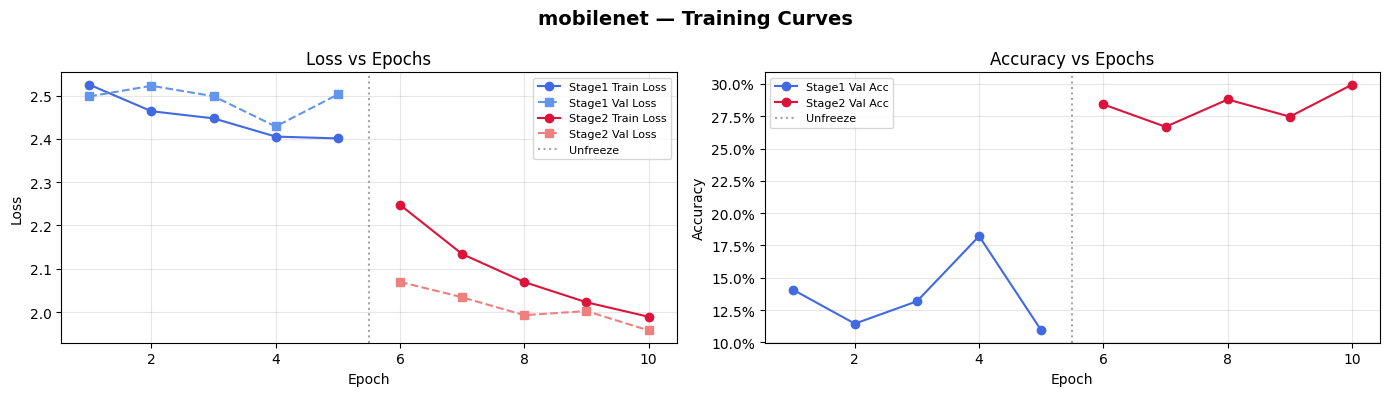

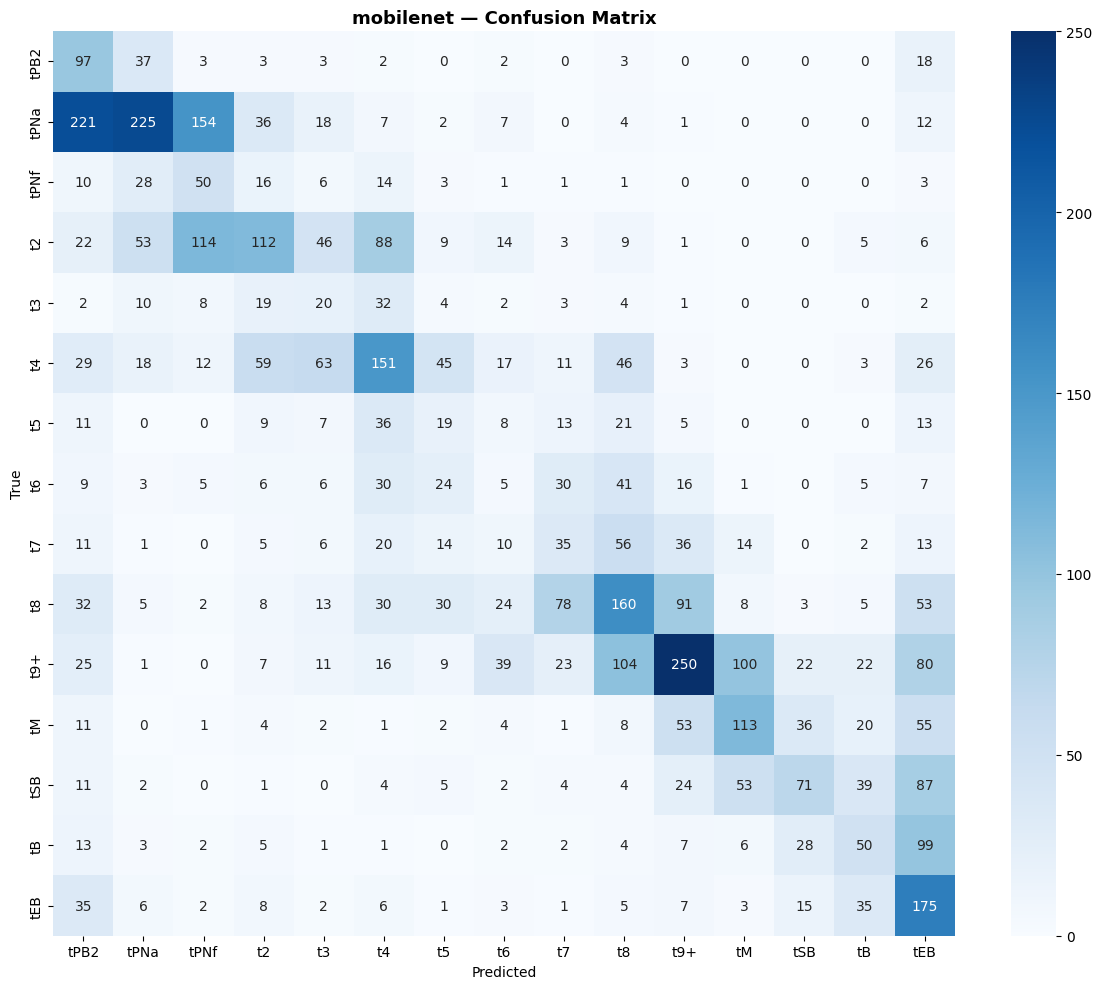

   Saved: mobilenet_best.pth

   Training: INCEPTIONV3

  Stage 1: Frozen backbone — CrossEntropy — LR=0.001
  Epoch 1/5 | Loss: 3.7438 | ValLoss: 2.6144 | Acc: 0.1663 | F1: 0.1218
  Epoch 2/5 | Loss: 3.7304 | ValLoss: 2.5018 | Acc: 0.1828 | F1: 0.1552
  Epoch 3/5 | Loss: 3.7578 | ValLoss: 2.6588 | Acc: 0.1647 | F1: 0.1315
  Epoch 4/5 | Loss: 3.6191 | ValLoss: 2.4730 | Acc: 0.2316 | F1: 0.1788
  Epoch 5/5 | Loss: 3.5517 | ValLoss: 2.4522 | Acc: 0.2136 | F1: 0.2013

 Stage 2: Unfrozen backbone — HybridLoss — LR=0.0001
  Epoch 1/5 | Loss: 3.1697 | ValLoss: 2.0572 | Acc: 0.2376 | F1: 0.2193
  Epoch 2/5 | Loss: 3.0019 | ValLoss: 2.0073 | Acc: 0.2703 | F1: 0.2806
  Epoch 3/5 | Loss: 2.9028 | ValLoss: 1.9618 | Acc: 0.3011 | F1: 0.3018
  Epoch 4/5 | Loss: 2.8061 | ValLoss: 1.9540 | Acc: 0.3104 | F1: 0.3086
  Epoch 5/5 | Loss: 2.7143 | ValLoss: 1.8940 | Acc: 0.3253 | F1: 0.3316

 Final Test Evaluation...
   Test Acc  : 0.3252
   Precision : 0.3715
   Recall    : 0.3252
   F1 Score  : 0.3269


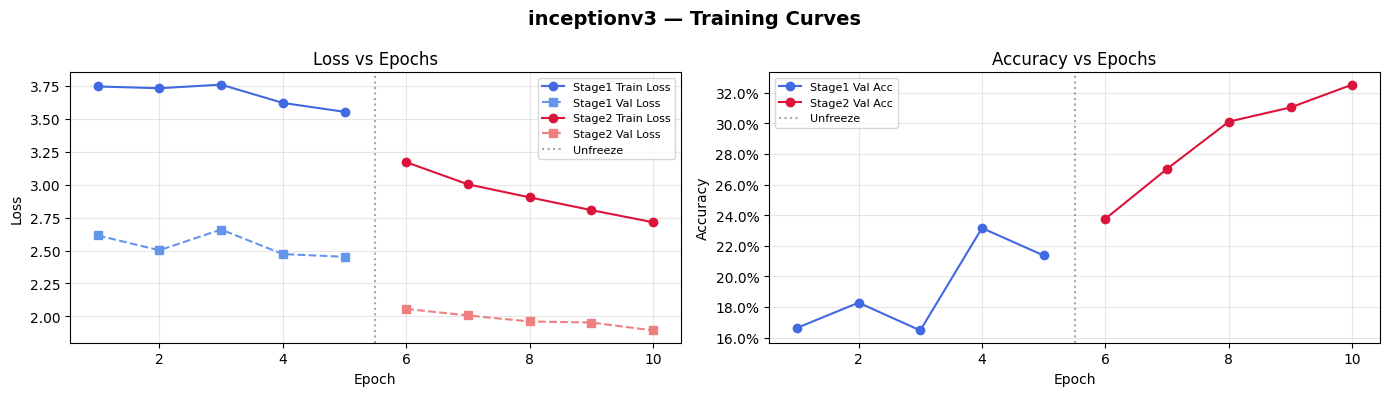

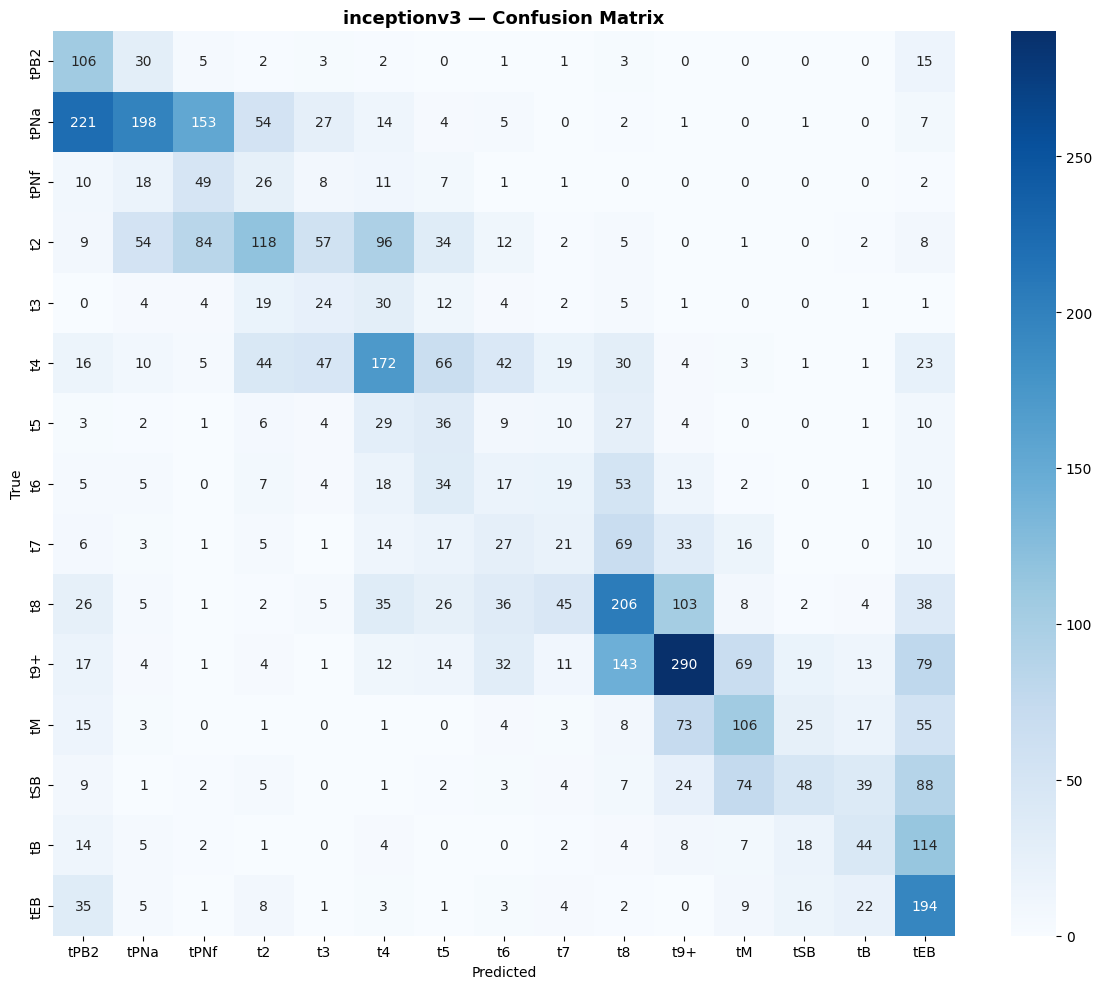

   Saved: inceptionv3_best.pth

   Training: VGG16

  Stage 1: Frozen backbone — CrossEntropy — LR=0.001
  Epoch 1/5 | Loss: 2.8881 | ValLoss: 2.7106 | Acc: 0.0689 | F1: 0.0093
  Epoch 2/5 | Loss: 2.7354 | ValLoss: 2.7101 | Acc: 0.0992 | F1: 0.0179
  Epoch 3/5 | Loss: 2.7259 | ValLoss: 2.7045 | Acc: 0.0518 | F1: 0.0052
  Epoch 4/5 | Loss: 2.7120 | ValLoss: 2.7019 | Acc: 0.0992 | F1: 0.0179
  Epoch 5/5 | Loss: 2.7091 | ValLoss: 2.7310 | Acc: 0.0961 | F1: 0.0203

 Stage 2: Unfrozen backbone — HybridLoss — LR=0.0001
  Epoch 1/5 | Loss: 2.6036 | ValLoss: 2.7002 | Acc: 0.1378 | F1: 0.0334
  Epoch 2/5 | Loss: 2.6021 | ValLoss: 2.6997 | Acc: 0.1532 | F1: 0.0407
  Epoch 3/5 | Loss: 2.6011 | ValLoss: 2.6985 | Acc: 0.1532 | F1: 0.0407
  Epoch 4/5 | Loss: 2.6010 | ValLoss: 2.6981 | Acc: 0.1378 | F1: 0.0334
  Epoch 5/5 | Loss: 2.6005 | ValLoss: 2.6961 | Acc: 0.1532 | F1: 0.0407

 Final Test Evaluation...
   Test Acc  : 0.1415
   Precision : 0.0200
   Recall    : 0.1415
   F1 Score  : 0.0351


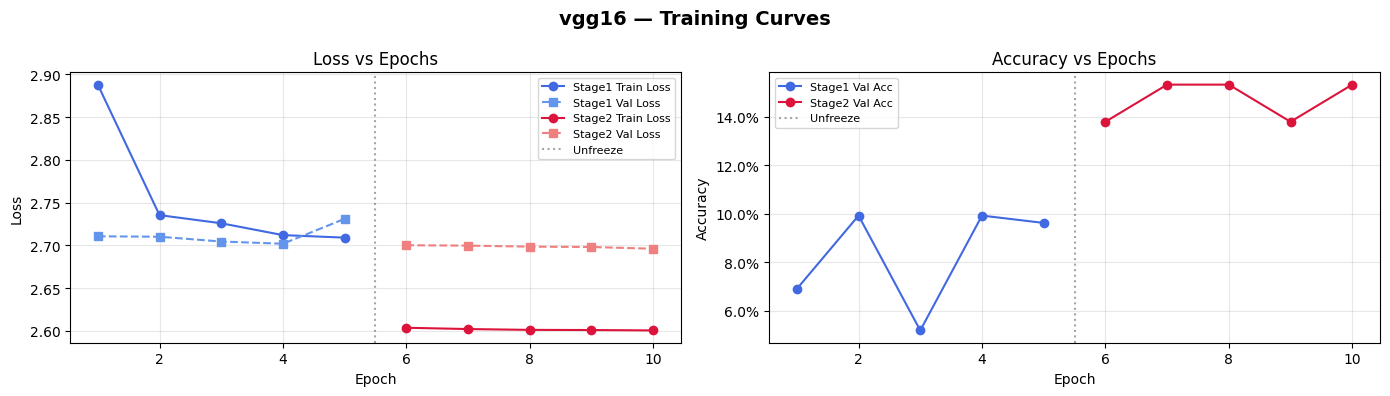

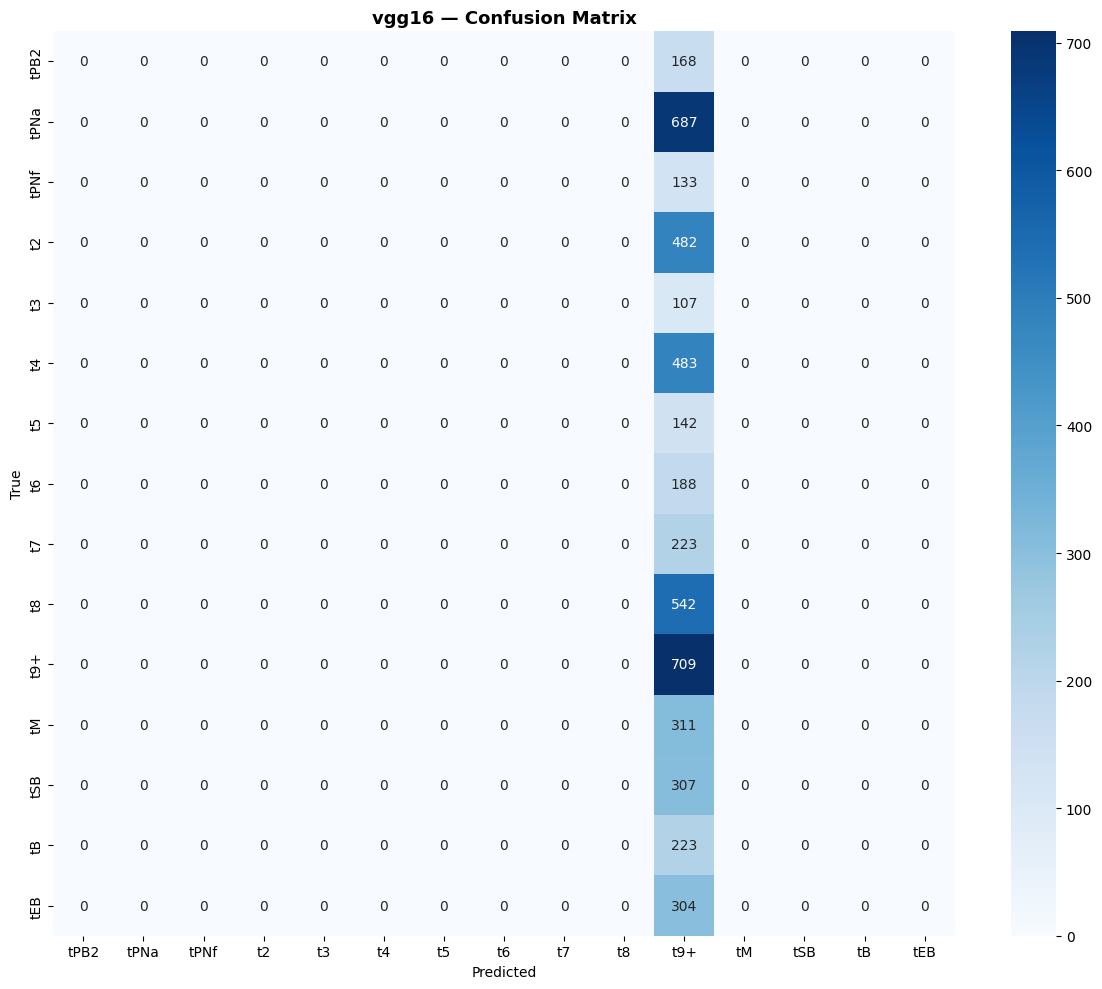

   Saved: vgg16_best.pth

   Training: VGG19

  Stage 1: Frozen backbone — CrossEntropy — LR=0.001
  Epoch 1/5 | Loss: 2.8591 | ValLoss: 2.6922 | Acc: 0.0262 | F1: 0.0021
  Epoch 2/5 | Loss: 2.7301 | ValLoss: 2.7017 | Acc: 0.0893 | F1: 0.0151
  Epoch 3/5 | Loss: 2.7135 | ValLoss: 2.7010 | Acc: 0.0992 | F1: 0.0183
  Epoch 4/5 | Loss: 2.7170 | ValLoss: 2.6971 | Acc: 0.0895 | F1: 0.0147
  Epoch 5/5 | Loss: 2.7092 | ValLoss: 2.7024 | Acc: 0.1469 | F1: 0.0565

 Stage 2: Unfrozen backbone — HybridLoss — LR=0.0001
  Epoch 1/5 | Loss: 2.5964 | ValLoss: 2.6968 | Acc: 0.1532 | F1: 0.0407
  Epoch 2/5 | Loss: 2.5813 | ValLoss: 2.6403 | Acc: 0.1290 | F1: 0.0539
  Epoch 3/5 | Loss: 2.4394 | ValLoss: 2.3797 | Acc: 0.1975 | F1: 0.1951
  Epoch 4/5 | Loss: 2.2406 | ValLoss: 2.1274 | Acc: 0.2858 | F1: 0.2777
  Epoch 5/5 | Loss: 2.1591 | ValLoss: 2.1042 | Acc: 0.3037 | F1: 0.2962

 Final Test Evaluation...
   Test Acc  : 0.3168
   Precision : 0.3226
   Recall    : 0.3168
   F1 Score  : 0.3074


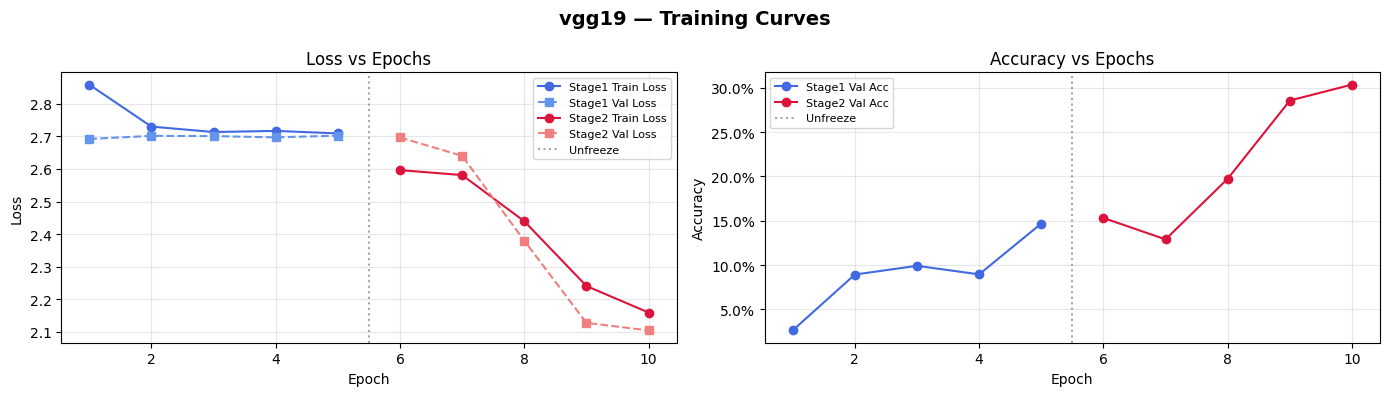

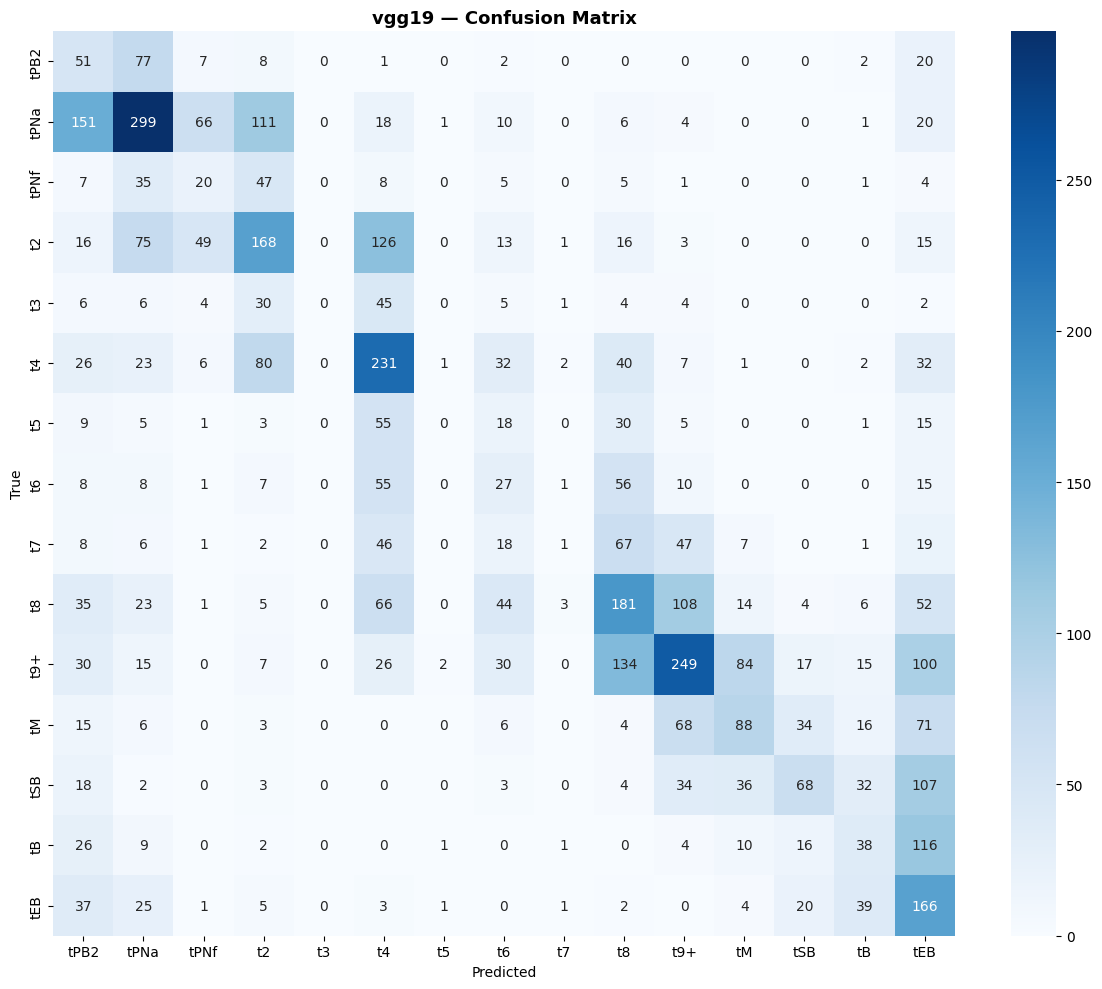

   Saved: vgg19_best.pth

 All models trained!


In [11]:
# ── Loss functions ────────────────────────────────────────────
ce_loss_fn     = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
hybrid_loss_fn = HybridLoss(CLASS_WEIGHTS)

MODEL_NAMES = ['mobilenet', 'inceptionv3', 'vgg16' , 'vgg19']

results_summary = {}
all_histories   = {}

for model_name in MODEL_NAMES:
    print('\n' + '='*60)
    print(f'   Training: {model_name.upper()}')
    print('='*60)

    is_inc = (model_name == 'inceptionv3')


    img_size = 299 if is_inc else 224
    train_transform, val_transform = get_transforms(img_size)
    train_loader, val_loader, test_loader = get_dataloaders(train_df, val_df, test_df, train_transform, val_transform)

    # ─── Build model (frozen backbone) ───
    model = get_model(model_name, freeze_backbone=True)
    model = model.to(DEVICE)

    history = {
        's1_loss': [], 's1_val_loss': [], 's1_acc': [],
        's2_loss': [], 's2_val_loss': [], 's2_acc': [],
    }

    # ─────────────────────────────────────────────────────────
    # STAGE 1 — Freeze backbone, train classifier only
    # ─────────────────────────────────────────────────────────
    print(f'\n  Stage 1: Frozen backbone — CrossEntropy — LR={STAGE1_LR}')
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=STAGE1_LR
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    for epoch in range(1, STAGE1_EPOCHS + 1):
        model.train()
        total_loss = 0

        for imgs, labs in train_loader:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)

            if is_inc:
                main_out, aux_out = outputs
                loss1 = ce_loss_fn(main_out, labs)
                loss2 = ce_loss_fn(aux_out, labs)
                loss = loss1 + 0.4 * loss2
            else:
                loss = ce_loss_fn(outputs, labs)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        val_metrics = evaluate(model, val_loader, is_inc)

        model.eval()
        val_loss_total, val_n = 0.0, 0
        with torch.no_grad():
            for imgs, labs in val_loader:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                out = model(imgs)

                if is_inc and isinstance(out, tuple):
                    out = out[0]

                val_loss_total += ce_loss_fn(out, labs).item() * imgs.size(0)
                val_n += imgs.size(0)

        val_loss = val_loss_total / val_n

        history['s1_loss'].append(train_loss)
        history['s1_val_loss'].append(val_loss)
        history['s1_acc'].append(val_metrics['acc'])

        print(f'  Epoch {epoch}/{STAGE1_EPOCHS} | '
              f'Loss: {train_loss:.4f} | ValLoss: {val_loss:.4f} | '
              f'Acc: {val_metrics["acc"]:.4f} | F1: {val_metrics["f1"]:.4f}')
        scheduler.step()

    # ─────────────────────────────────────────────────────────
    # STAGE 2 — Unfreeze ALL, HybridLoss, lower LR
    # ─────────────────────────────────────────────────────────
    print(f'\n Stage 2: Unfrozen backbone — HybridLoss — LR={STAGE2_LR}')
    for p in model.parameters():
        p.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=STAGE2_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=STAGE2_EPOCHS)

    for epoch in range(1, STAGE2_EPOCHS + 1):
        model.train()
        total_loss = 0

        for imgs, labs in train_loader:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)

            if is_inc:
                main_out, aux_out = outputs
                loss1 = hybrid_loss_fn(main_out, labs)
                loss2 = hybrid_loss_fn(aux_out, labs)
                loss = loss1 + 0.4 * loss2
            else:
                loss = hybrid_loss_fn(outputs, labs)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        val_metrics = evaluate(model, val_loader, is_inc)

        model.eval()
        val_loss_total, val_n = 0.0, 0
        with torch.no_grad():
            for imgs, labs in val_loader:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                out = model(imgs)

                if is_inc and isinstance(out, tuple):
                    out = out[0]

                val_loss_total += ce_loss_fn(out, labs).item() * imgs.size(0)
                val_n += imgs.size(0)

        val_loss = val_loss_total / val_n

        history['s2_loss'].append(train_loss)
        history['s2_val_loss'].append(val_loss)
        history['s2_acc'].append(val_metrics['acc'])

        print(f'  Epoch {epoch}/{STAGE2_EPOCHS} | '
              f'Loss: {train_loss:.4f} | ValLoss: {val_loss:.4f} | '
              f'Acc: {val_metrics["acc"]:.4f} | F1: {val_metrics["f1"]:.4f}')
        scheduler.step()

    # ─────────────────────────────────────────────────────────
    # Final Test Evaluation
    # ─────────────────────────────────────────────────────────
    print('\n Final Test Evaluation...')
    test_metrics = evaluate(model, test_loader, is_inc)

    results_summary[model_name] = test_metrics
    all_histories[model_name]   = history

    print(f'   Test Acc  : {test_metrics["acc"]:.4f}')
    print(f'   Precision : {test_metrics["prec"]:.4f}')
    print(f'   Recall    : {test_metrics["rec"]:.4f}')
    print(f'   F1 Score  : {test_metrics["f1"]:.4f}')

    plot_curves(history, model_name)
    plot_confusion_matrix(test_metrics['cm'], model_name)

    torch.save(model.state_dict(), f'{model_name}_best.pth')
    print(f'   Saved: {model_name}_best.pth')

    del model
    torch.cuda.empty_cache()

print('\n All models trained!')

**bold text**##  Cell 12 — Per-Class Classification Report

In [12]:
for mname, metrics in results_summary.items():
    print(f'\n{"="*55}')
    print(f'   {mname.upper()} — Classification Report')
    print('='*55)
    print(classification_report(
        metrics['labels'], metrics['preds'],
        target_names=PHASES, zero_division=0
    ))


   MOBILENET — Classification Report
              precision    recall  f1-score   support

        tPB2       0.18      0.58      0.27       168
        tPNa       0.57      0.33      0.42       687
        tPNf       0.14      0.38      0.21       133
          t2       0.38      0.23      0.29       482
          t3       0.10      0.19      0.13       107
          t4       0.34      0.31      0.33       483
          t5       0.11      0.13      0.12       142
          t6       0.04      0.03      0.03       188
          t7       0.17      0.16      0.16       223
          t8       0.34      0.30      0.32       542
         t9+       0.51      0.35      0.42       709
          tM       0.38      0.36      0.37       311
         tSB       0.41      0.23      0.29       307
          tB       0.27      0.22      0.24       223
         tEB       0.27      0.58      0.37       304

    accuracy                           0.31      5009
   macro avg       0.28      0.29      0.2

##  Cell 13 — Model Comparison Table

In [13]:
rows = []
for mname, metrics in results_summary.items():
    rows.append({
        'Model'    : mname.upper(),
        'Accuracy' : f"{metrics['acc']*100:.2f}%",
        'Precision': f"{metrics['prec']*100:.2f}%",
        'Recall'   : f"{metrics['rec']*100:.2f}%",
        'F1 Score' : f"{metrics['f1']*100:.2f}%",
    })

comparison_df = pd.DataFrame(rows)
print('\n Model Comparison Table')
print('='*65)
print(comparison_df.to_string(index=False))
print('='*65)

# Styled HTML in notebook
comparison_df.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color','#2c3e50'),
                                   ('color','white'),('font-size','13px')]},
    {'selector': 'td', 'props': [('text-align','center')]}
]).set_caption(' Embryo Classification — Model Comparison')


🏆 Model Comparison Table
      Model Accuracy Precision Recall F1 Score
  MOBILENET   30.60%    35.73% 30.60%   31.30%
INCEPTIONV3   32.52%    37.15% 32.52%   32.69%
      VGG16   14.15%     2.00% 14.15%    3.51%
      VGG19   31.68%    32.26% 31.68%   30.74%


,Model,Accuracy,Precision,Recall,F1 Score
0,MOBILENET,30.60%,35.73%,30.60%,31.30%
1,INCEPTIONV3,32.52%,37.15%,32.52%,32.69%
2,VGG16,14.15%,2.00%,14.15%,3.51%
3,VGG19,31.68%,32.26%,31.68%,30.74%


##  Cell 14 — Side-by-Side Accuracy Comparison Plot

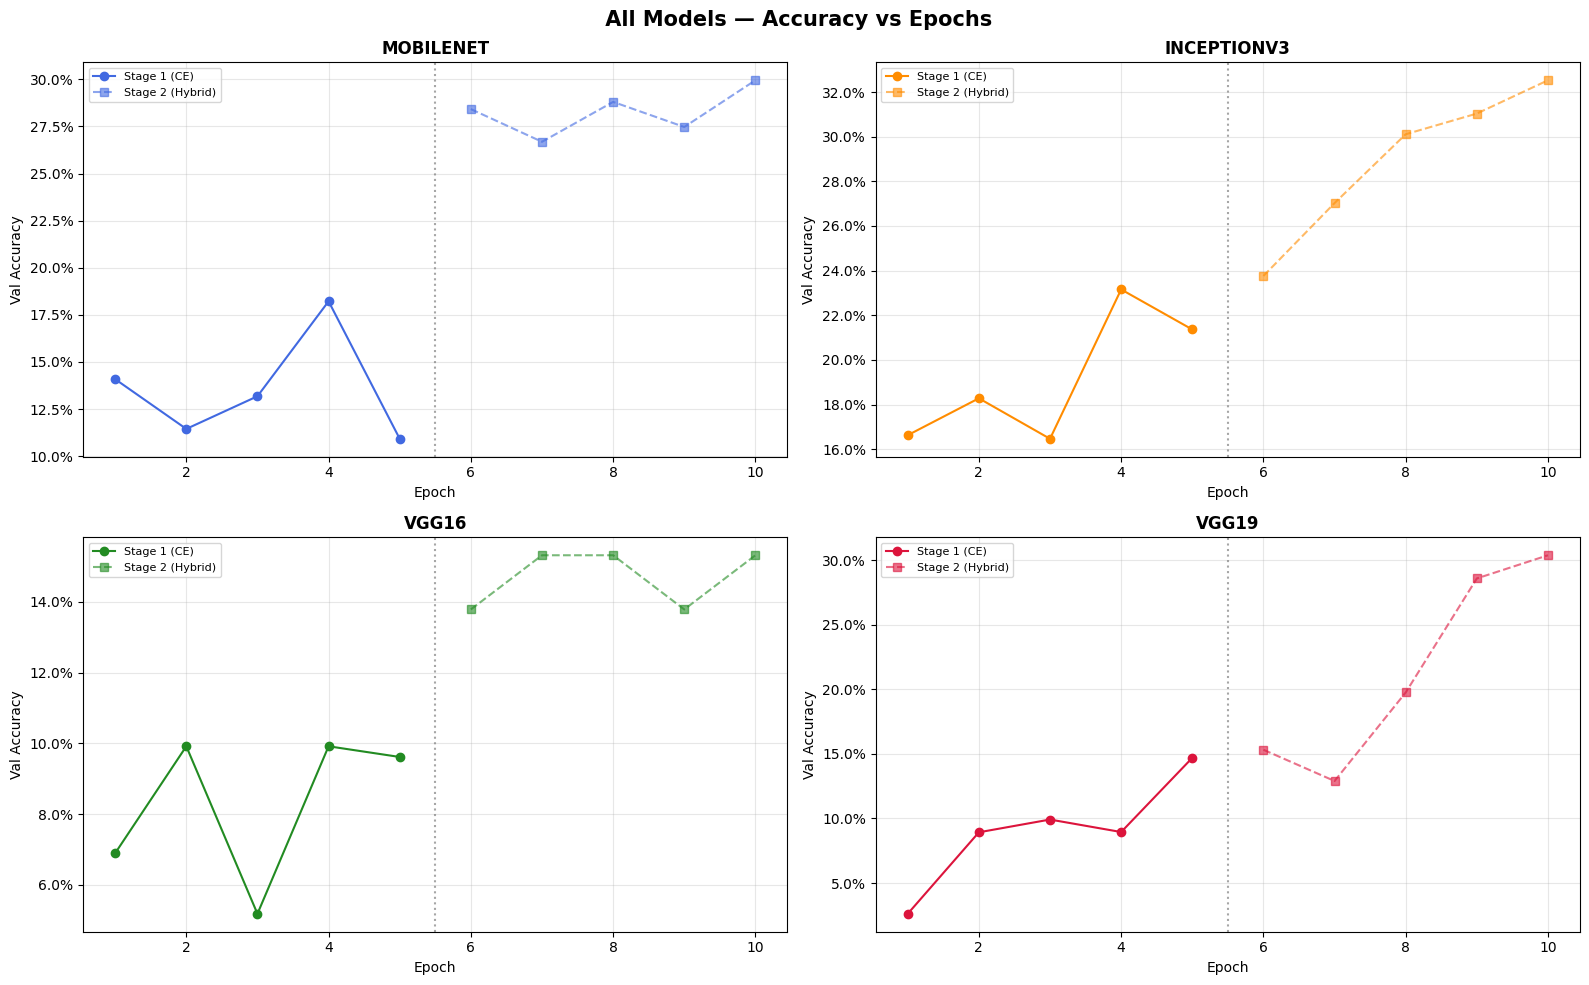

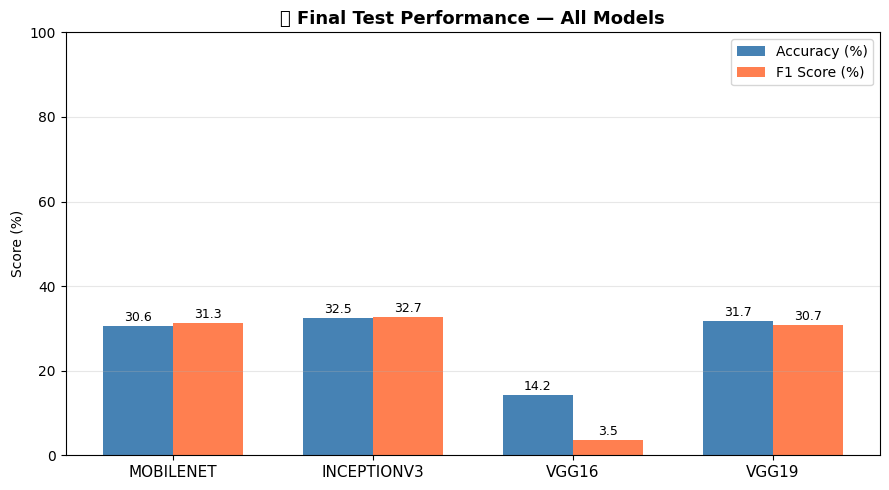

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(' All Models — Accuracy vs Epochs', fontsize=15, fontweight='bold')
axes = axes.flatten()

colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson']

for i, (mname, hist) in enumerate(all_histories.items()):
    ax = axes[i]
    ep_s1 = range(1, STAGE1_EPOCHS + 1)
    ep_s2 = range(STAGE1_EPOCHS + 1, STAGE1_EPOCHS + STAGE2_EPOCHS + 1)

    ax.plot(ep_s1, hist['s1_acc'], 'o-', color=colors[i], label='Stage 1 (CE)')
    ax.plot(ep_s2, hist['s2_acc'], 's--', color=colors[i], alpha=0.6, label='Stage 2 (Hybrid)')
    ax.axvline(STAGE1_EPOCHS + 0.5, color='gray', linestyle=':', alpha=0.7)
    ax.set_title(mname.upper(), fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_accuracy.png', dpi=120)
plt.show()

# Bar chart: final test accuracy
fig, ax = plt.subplots(figsize=(9, 5))
mnames = [m.upper() for m in results_summary]
accs   = [results_summary[m]['acc'] * 100 for m in results_summary]
f1s    = [results_summary[m]['f1']  * 100 for m in results_summary]

x = np.arange(len(mnames))
w = 0.35
ax.bar(x - w/2, accs, w, label='Accuracy (%)', color='steelblue')
ax.bar(x + w/2, f1s,  w, label='F1 Score (%)',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(mnames, fontsize=11)
ax.set_ylim(0, 100)
ax.set_ylabel('Score (%)')
ax.set_title(' Final Test Performance — All Models', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=120)
plt.show()

##  Cell 15 — Result Analysis & Trade-offs

In [15]:
# Identify best model by F1
best_model = max(results_summary, key=lambda m: results_summary[m]['f1'])
best_f1    = results_summary[best_model]['f1']
best_acc   = results_summary[best_model]['acc']

print('='*60)
print(f' BEST MODEL  : {best_model.upper()}')
print(f'   Accuracy    : {best_acc*100:.2f}%')
print(f'   F1 Score    : {best_f1*100:.2f}%')
print('='*60)

print("""
 ANALYSIS — WHY ONE MODEL OUTPERFORMS OTHERS
═══════════════════════════════════════════════

MobileNetV2:
  Lightest model (~3.4M params) — fastest training
   Depthwise separable convolutions → efficient
    May miss fine-grained embryo texture features
   Best for: real-time / edge deployment

InceptionV3:
   Multi-scale receptive fields via inception modules
   Auxiliary loss helps with gradient flow (15 classes)
    Needs 299×299 input for optimal performance
   Best for: when accuracy > speed

VGG16:
   Simple, deep, uniform architecture
   Strong spatial feature extraction
    ~138M params — heavy memory usage
   Best for: transfer learning baseline

VGG19:
   Deeper than VGG16 — more feature hierarchy
    Largest model — slowest training
    Prone to overfitting on small datasets
   Best for: large dataset scenarios

 HybridLoss Impact:
  • CrossEntropy provides stable gradients throughout
  • Focal component forces model to learn hard phases
    (e.g. t3/t4 which have few training examples)
  • Label smoothing prevents over-confident predictions
    on ambiguous embryo stage boundaries

 Speed vs Accuracy Trade-off:
  Fastest  ──── MobileNet → InceptionV3 → VGG16 → VGG19 ──── Most params
  Lightest ──── MobileNet → InceptionV3 → VGG16 → VGG19 ──── Heaviest
""")

🏆 BEST MODEL  : INCEPTIONV3
   Accuracy    : 32.52%
   F1 Score    : 32.69%

 ANALYSIS — WHY ONE MODEL OUTPERFORMS OTHERS
═══════════════════════════════════════════════

MobileNetV2:
  Lightest model (~3.4M params) — fastest training
   Depthwise separable convolutions → efficient
    May miss fine-grained embryo texture features
   Best for: real-time / edge deployment

InceptionV3:
   Multi-scale receptive fields via inception modules
   Auxiliary loss helps with gradient flow (15 classes)
    Needs 299×299 input for optimal performance
   Best for: when accuracy > speed

VGG16:
   Simple, deep, uniform architecture
   Strong spatial feature extraction
    ~138M params — heavy memory usage
   Best for: transfer learning baseline

VGG19:
   Deeper than VGG16 — more feature hierarchy
    Largest model — slowest training
    Prone to overfitting on small datasets
   Best for: large dataset scenarios

 HybridLoss Impact:
  • CrossEntropy provides stable gradients throughout
  • Focal co